In [1]:
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.linalg import solve, eigh

# Sayısal Kararlılık Sabitleri
EPS = 1e-8
np.seterr(over='ignore', under='ignore', divide='ignore')

# =============================================================================
# 1. RANDOM FOURIER FEATURES (RFF) SINIFI
# =============================================================================
class RFF:
    def __init__(self, m, d, sigma, seed=None):
        """
        m     : RFF boyutu (özellik sayısı)
        d     : Girdi boyutu
        sigma : RBF bant genişliği
        seed  : Rastgele tohum
        """
        self.m = m
        self.d = d
        self.sigma = sigma
        self.seed = seed
        rng = np.random.default_rng(seed)

        # w_j ~ N(0, sigma^-2 * I_d) -> Bochner Teoremi gereği
        self.omega = rng.normal(scale=1.0 / sigma, size=(m, d))
        # b_j ~ Uniform(0, 2pi)
        self.b = rng.uniform(0, 2 * np.pi, size=m)

    def phi(self, X):
        """
        φ(x) = √(2/m) · cos(Ωx + b)
        Karmaşıklık: O(ndm)
        """
        return np.sqrt(2 / self.m) * np.cos(X @ self.omega.T + self.b)


# =============================================================================
# 2. RFF-COX SINIFI (FINAL VERSION - FULL INVERSE & STABLE)
# =============================================================================
class RFCox:
    def __init__(self, m, l2=1e-3, seed=42):
        """
        m   : RFF boyutu
        l2  : Ridge düzenlileştirme (λ > 0)
        seed: Rastgele tohum
        """
        self.m = m
        self.l2 = l2
        self.seed = seed
        self.kernel = None
        self.coef_ = None
        self.std_ = None       # SE(beta) - Full Inverse ile hesaplanır
        self.cov_matrix_ = None # Opsiyonel: Tam kovaryans matrisi
        self.sigma_ = None
        self.baseline_times_ = None
        self.baseline_H0_ = None

    # =========================================================================
    # SIGMA SEÇİMİ — LAPLACE YAKLAŞIMI (Algoritma 1, Adım 1)
    # =========================================================================
    def _select_sigma(self, X, T, E):
        n, d = X.shape
        rng = np.random.default_rng(self.seed)
        # Hızlandırma için alt örnekleme
        idx = rng.choice(n, min(300, n), replace=False)
        
        # Medyan heuristiği ile başlangıç aralığı
        dists = np.linalg.norm(X[idx][:, None, :] - X[idx][None, :, :], axis=2)
        sigma_med = np.median(dists[dists > 0]) if np.any(dists > 0) else 1.0
        
        # Eğer medyan hesaplanamazsa basit bir tahmin
        if not np.isfinite(sigma_med) or sigma_med <= 0:
            sigma_med = np.median(np.linalg.norm(X[idx], axis=1)) * np.sqrt(2)

        def laplace_objective(log_sigma):
            sigma = np.exp(log_sigma)
            kernel = RFF(self.m, d, sigma, self.seed)
            try:
                # Hızlı yakınsama (5 iterasyon) sadece skor almak için
                ll, fisher, _ = self._fit_cox_core(kernel, X, T, E, max_iter=5, return_beta=True)
                
                # Penalize log-likelihood
                # Not: Beta henüz tam yakınsamadığı için ceza terimi yaklaşık olarak eklenir
                # Ancak Laplace skoru için ana odak ll ve det(I)'dir.
                
                sign, logdet = np.linalg.slogdet(fisher)
                if sign <= 0 or not np.isfinite(logdet):
                    return 1e10
                
                # Laplace Score: L ≈ l_pen - 0.5 * log det I
                # Burada l_pen yerine hızlı ll kullanıyoruz, bu yeterince iyi bir yönlendiricidir.
                score = -(ll - 0.5 * logdet)
                return score
            except Exception:
                return 1e10

        # Arama aralığını güvenli hale getir
        sigma_min = max(0.1 * sigma_med, 1e-6)
        sigma_max = 10.0 * sigma_med
        
        res = minimize_scalar(
            laplace_objective,
            bounds=(np.log(sigma_min), np.log(sigma_max)),
            method="bounded",
            options={'xatol': 1e-4}
        )
        return np.exp(res.x)

    # =========================================================================
    # CORE OPTİMİZASYON — NEWTON-RAPHSON (Algoritma 1, Adım 3)
    # =========================================================================
    def _fit_cox_core(self, kernel, X, T, E, max_iter=20, return_beta=False):
        Phi = kernel.phi(X)
        
        # Sıralama (Risk kümesi için şart)
        order = np.argsort(T)
        T_ord = T[order]
        E_ord = E[order]
        Phi_ord = Phi[order]
        
        beta = np.zeros(self.m)

        for _ in range(max_iter):
            eta = Phi_ord @ beta
            
            # Sayısal stabilite: exp overflow koruması
            risk = np.exp(np.clip(eta, -700, 700))
            risk = np.nan_to_num(risk, posinf=1e20, neginf=0.0)
            
            # Ters kümülatif toplam (Risk seti toplamı) - O(n)
            cum_risk = np.flip(np.cumsum(np.flip(risk)))
            cum_risk = np.maximum(cum_risk, EPS)
            
            # Breslow ağırlıkları ve Working weights
            # H_i = sum_{j<=i, event} 1 / R(T_j)
            # Daha verimli hesaplama için vektörel yaklaşım:
            # Mask events
            mask_events = (E_ord == 1)
            
            # Event zamanlarındaki ters risk toplamları
            inv_cum_risk_at_events = np.zeros_like(T_ord, dtype=float)
            inv_cum_risk_at_events[mask_events] = 1.0 / cum_risk[mask_events]
            
            # Kümülatif tehlike artışı (H)
            # H değeri her adım için değil, risk çarpanı mu için gerekli
            # Mu_i = r_i * sum_{j<=i, event} (1/R_j)
            # Bu toplamı cumulative sum ile alalım
            H_increment = np.cumsum(inv_cum_risk_at_events)
            
            mu = risk * H_increment
            
            # Skor vektörü U(beta)
            score = Phi_ord.T @ (E_ord - mu) - self.l2 * beta
            
            # Fisher Bilgi Matrisi I(beta) = Φᵀ diag(μ) Φ + (λ + ε)I
            # Verimlilik için: (Phi.T * mu) @ Phi
            fisher = (Phi_ord.T * mu) @ Phi_ord + (self.l2 + EPS) * np.eye(self.m)
            
            # Simetri garantisi (sayısal hata olabilir)
            fisher = (fisher + fisher.T) * 0.5
            
            try:
                # Newton Adımı: delta = I^-1 U
                delta = solve(fisher, score)
                beta += delta
                
                if np.linalg.norm(delta) < 1e-6:
                    break
            except np.linalg.LinAlgError:
                # Nadir durum: matris tekil ise dur
                break

        # Final Log-Likelihood Hesabı
        eta_final = Phi_ord @ beta
        risk_final = np.exp(np.clip(eta_final, -700, 700))
        cum_risk_final = np.flip(np.cumsum(np.flip(risk_final)))
        cum_risk_final = np.maximum(cum_risk_final, EPS)
        
        ll = np.sum(E_ord * (eta_final - np.log(cum_risk_final)))
        ll -= 0.5 * self.l2 * np.sum(beta ** 2) # Penalized LL

        if return_beta:
            return ll, fisher, beta
        return ll, fisher

    # =========================================================================
    # BASELINE HAZARD (BRESLOW) (Algoritma 1, Adım 4)
    # =========================================================================
    def _compute_breslow_baseline(self, X, T, E):
        Phi = self.kernel.phi(X)
        eta = Phi @ self.coef_
        risk = np.exp(np.clip(eta, -700, 700))
        risk = np.nan_to_num(risk, posinf=1e20, neginf=0.0)

        order = np.argsort(T)
        T_s = T[order]
        E_s = E[order]
        r_s = risk[order]

        uniq_times = np.unique(T_s[E_s == 1])
        
        if len(uniq_times) == 0:
            self.baseline_times_ = np.array([0.0])
            self.baseline_H0_ = np.array([0.0])
            return

        H0_vals = []
        cum_H0 = 0.0
        
        # Verimli hesaplama için önceden sıralı risk toplamını kullanabiliriz ama
        # tied events düzeltmesi için döngü daha güvenlidir (n küçük/orta ise)
        # Büyük veri için vektörelleştirilmiş versiyon da yazılabilir.
        
        # Risk seti toplamlarını önceden hesapla (T sıralı olduğu için)
        # R(t) = sum_{j: Tj >= t} r_j
        # T_s zaten sıralı, yani geriye doğru kümülatif toplam
        total_risk_cum = np.flip(np.cumsum(np.flip(r_s)))
        
        # Her benzersiz olay zamanı için
        for t in uniq_times:
            # t zamanındaki olaylar
            mask_time = (T_s == t)
            d_t = np.sum(mask_time & (E_s == 1))
            
            # Risk seti toplamı: T >= t olanların risk toplamı
            # T_s sıralı olduğu için ilk oluşan indeks bul
            # Ancak np.searchsorted daha hızlıdır
            idx_start = np.searchsorted(T_s, t, side='left')
            denom = total_risk_cum[idx_start] if idx_start < len(T_s) else 0.0
            
            if denom > 1e-12:
                cum_H0 += d_t / denom
            
            H0_vals.append(cum_H0)

        self.baseline_times_ = uniq_times
        self.baseline_H0_ = np.array(H0_vals)

    # =========================================================================
    # FIT (Algoritma 1 Ana Akışı)
    # =========================================================================
    def fit(self, X, T, E, auto_sigma=True):
        n, d = X.shape
        
        # 1. Sigma Seçimi (Laplace)
        if auto_sigma:
            sigma = self._select_sigma(X, T, E)
        else:
            sigma = 1.0
            
        # 2. RFF Mapping
        self.kernel = RFF(self.m, d, sigma, self.seed)
        
        # 3. Optimizasyon (Newton-Raphson)
        _, fisher, beta = self._fit_cox_core(self.kernel, X, T, E, max_iter=20, return_beta=True)
        
        self.coef_ = beta
        self.sigma_ = sigma
        
        # 4. STANDART HATALAR: FULL INVERSE (Wald Theory)
        # Diagonal approximation KALDIRILDI. Tam kovaryans hesaplanıyor.
        try:
            # Eigen Decomposition ile Stabilize Edilmiş Ters Alma
            # Fisher simetrik olmalı ama sayısal hatalara karşı tekrar garanti edelim
            fisher_sym = (fisher + fisher.T) * 0.5
            
            # Özdeğer ayrıştırması
            eigen_vals, eigen_vecs = eigh(fisher_sym)
            
            # Küçük özdeğerleri kes (Thresholding) - Sayısal Patlamayı Önler
            # Lambda'dan bağımsız mutlak bir alt sınır veya lambda'nın bir fraksiyonu
            min_eig_threshold = max(1e-8, self.l2 * 0.1) 
            eigen_vals_clipped = np.clip(eigen_vals, min_eig_threshold, None)
            
            # Tersini Al: V * diag(1/val) * V.T
            inv_eigen_vals = 1.0 / eigen_vals_clipped
            cov_matrix = (eigen_vecs * inv_eigen_vals) @ eigen_vecs.T
            
            self.cov_matrix_ = cov_matrix
            variances = np.diag(cov_matrix)
            
            # Negatif varyans oluşumunu (sayısal artefakt) engelle
            variances = np.maximum(variances, EPS)
            self.std_ = np.sqrt(variances)
            
        except Exception as e:
            print(f"Warning: Full matrix inversion failed ({str(e)}). Falling back to diagonal approximation.")
            # En kötü ihtimal diyagonale düş (Literatürdeki eski yöntem)
            self.std_ = 1.0 / np.sqrt(np.diag(fisher) + EPS)
            self.cov_matrix_ = None
        
        # 5. Baseline Hazard
        self._compute_breslow_baseline(X, T, E)
        
        return self

    # =========================================================================
    # PREDICT (LINEAR PREDICTOR & SE)
    # =========================================================================
    def predict(self, X, return_std=False):
        """
        η(x) = φ(x)ᵀβ̂
        Var(η) = φ(x)ᵀ Cov(β̂) φ(x)  (Tam formül)
        Eğer cov_matrix_ yoksa (fallback durumu), diagonal approx kullanır.
        """
        Phi = self.kernel.phi(X)
        mean = Phi @ self.coef_
        
        if not return_std:
            return mean
            
        if self.cov_matrix_ is not None:
            # Tam Kovaryans ile Varyans: diag(Phi * Cov * Phi.T)
            # Verimlilik için: sum_j sum_k Phi_ij * Cov_jk * Phi_ik
            # Veya: (Phi @ cov_matrix) * Phi şeklinde satır bazlı çarpım
            var = np.sum((Phi @ self.cov_matrix_) * Phi, axis=1)
        else:
            # Fallback: Diagonal Approx
            var = (Phi ** 2) @ (self.std_ ** 2)
            
        var = np.maximum(var, EPS)
        std = np.sqrt(var)
        return mean, std

    # =========================================================================
    # PARTIAL HAZARD (STANDART - DÜZELTMESİZ)
    # =========================================================================
    def predict_partial_hazard(self, X):
        """
        HR = exp(η)
        Literatür standardı gereği bias düzeltmesi uygulanmaz.
        """
        eta = self.predict(X)
        return np.exp(np.clip(eta, -700, 700))

    # =========================================================================
    # BASELINE INTERPOLATION
    # =========================================================================
    def _baseline_cumulative_hazard(self, t):
        t = np.atleast_1d(t)
        if self.baseline_H0_ is None or len(self.baseline_H0_) == 0:
            return np.zeros_like(t, dtype=float)
        return np.interp(
            t, 
            self.baseline_times_, 
            self.baseline_H0_, 
            left=0.0, 
            right=self.baseline_H0_[-1]
        )

    # =========================================================================
    # CUMULATIVE HAZARD & SURVIVAL
    # =========================================================================
    def predict_cumulative_hazard(self, X, t):
        H0 = self._baseline_cumulative_hazard(t)
        risk = self.predict_partial_hazard(X)
        return risk[:, None] * H0[None, :]

    def predict_survival_function(self, X, t):
        H = self.predict_cumulative_hazard(X, t)
        return np.exp(-np.clip(H, 0, 700))

    # =========================================================================
    # SURVIVAL CI (LOG-LOG TRANSFORM - TUTARLI)
    # =========================================================================
    def predict_survival_fast_ci(self, X, t, z=1.96):
        """
        Nokta tahmini ve Türev TAM TUTARLI hesaplanır.
        Log-Log dönüşümü ile [0,1] sınırlı asimetrik GA üretilir.
        """
        t = np.atleast_1d(t)
        eta, se_eta = self.predict(X, return_std=True)
        H0 = self._baseline_cumulative_hazard(t)

        # 1. NOKTA TAHMİNİ: S = exp(-H0 * exp(eta))
        risk_raw = np.exp(np.clip(eta, -700, 700))
        H = risk_raw[:, None] * H0[None, :]
        S = np.exp(-np.clip(H, 0, 700))

        # 2. VARYANS PROPAGASYONU (Delta Method)
        # dS/d_eta = -H0 * exp(eta) * S
        dS_deta = -(H0[None, :] * risk_raw[:, None]) * S
        Var_S = (dS_deta ** 2) * (se_eta[:, None] ** 2)

        # 3. LOG-LOG GA
        S_clip = np.clip(S, EPS, 1.0 - EPS)
        log_S = np.log(S_clip)
        neg_log_S = -log_S
        
        # u = ln(-ln(S))
        u = np.log(np.clip(neg_log_S, EPS, None))
        
        # Delta SE for u
        # Collett (2015) formülü: delta = SE(S) / (S * |ln(S)|)
        delta = np.sqrt(Var_S + EPS) / (S_clip * np.abs(log_S) + EPS)

        lower = np.exp(-np.exp(u + z * delta))
        upper = np.exp(-np.exp(u - z * delta))

        return S, np.clip(lower, 0, 1), np.clip(upper, 0, 1)

    # =========================================================================
    # HR CI (STANDART WALD)
    # =========================================================================
    def predict_hr_ci(self, X, z=1.96):
        """
        HR = exp(η)
        GA = [exp(η - z·SE), exp(η + z·SE)]
        """
        eta, se = self.predict(X, return_std=True)
        
        hr = np.exp(eta)
        hr_lower = np.exp(eta - z * se)
        hr_upper = np.exp(eta + z * se)
        
        return hr, hr_lower, hr_upper

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
#SON GÜNCELLEME
# ============================================================
# YARDIMCI: Nadir kategorileri birleştir
# ============================================================
def _merge_rare_categories(series, min_count=5):
    counts = series.value_counts()
    rare = counts[counts < min_count].index
    return series.replace(rare, "Other")

# ============================================================
# ÖN İŞLEME: Sayısal vs Kategorik ayır
# ============================================================
def get_preprocessor(X_df):
    num_cols = []
    cat_cols = []
    for col in X_df.columns:
        uniq_vals = X_df[col].dropna().unique()
        if len(uniq_vals) == 2 and set(uniq_vals) <= {0, 1}:
            cat_cols.append(col)  # binary → passthrough
        elif X_df[col].dtype in [np.float64, np.int64, np.float32, np.int32]:
            num_cols.append(col)  # sürekli → scale
        else:
            cat_cols.append(col)  # string/object → kategorik
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", "passthrough", cat_cols)
        ],
        remainder="drop"
    )

# ============================================================
# VERİ YÜKLEME FONKSİYONLARI (ZAMAN BİRİMİ: AY)
# ============================================================
import pandas as pd
import numpy as np


def load_support2_data(path="support2.csv"):
    df = pd.read_csv(path, skipinitialspace=True)
    df.columns = df.columns.str.strip()
    
    T = df["d.time"].values.astype(np.float64) / 30.44  # gün → ay
    E = df["death"].values.astype(np.int32)
    
    # Hedef sütunları çıkar
    df = df.drop(columns=["d.time", "death"])
    
    # *** HESAPLANMIŞ SKORLARI VE TAHMİNLERİ SİL ***
    score_cols = ['surv2m', 'surv6m', 'prg2m', 'prg6m', 
                  'aps', 'sps', 'scoma', 'adlp', 'adls', 'sfdm2', 'adlsc']
    df = df.drop(columns=[col for col in score_cols if col in df.columns])
    
    # Sayısal olmayan tüm sütunları kategorik olarak işaretle
    cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Kategorikleri temizle ve rare merge yap
    for col in cat_cols:
        df[col] = df[col].astype(str).fillna("Missing")
        df[col] = _merge_rare_categories(df[col], min_count=10)
    
    # One-hot encoding
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    
    # Şimdi tüm sütunlar sayısal!
    feature_cols = df.columns.tolist()
    
    # Eksik değerleri medyanla doldur (artık sadece sayısal var)
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    
    # Boolean'ları int'e çevir
    for col in feature_cols:
        if df[col].dtype == bool:
            df[col] = df[col].astype(np.int32)
    
    X = df[feature_cols].values.astype(np.float64)
    return X, T, E, feature_cols

def load_metabric_data():
    from pycox.datasets import metabric
    df = metabric.read_df()
    
    real_names = [
        "age", "menopause", "tumor_size", "inv_nodes", "nodes",
        "ER_status", "grade", "radiotherapy", "chemotherapy"
    ]
    
    feature_cols = [c for c in df.columns if c not in ["duration", "event"]]
    df_features = df[feature_cols].copy()
    df_features.columns = real_names
    
    # ❌ ESKİ: inplace=True ile chained assignment
    # ✅ YENİ: doğrudan atama
    for col in real_names:
        median_val = df_features[col].median()
        df_features[col] = df_features[col].fillna(median_val)
    
    X = df_features.values.astype(np.float64)
    T = df["duration"].values.astype(np.float64) # / 30.44  # gün → ay
    E = df["event"].values.astype(np.int32)
    
    return X, T, E, real_names

def load_flchain_data():
    url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/survival/flchain.csv"
    df = pd.read_csv(url)
    df = df.drop(columns=["Unnamed: 0", "rownames","chapter"], errors="ignore")
    
    # Gerekli sütunlar için NA'lı satırları sil
    #df = df.dropna(subset=["futime", "death", "chapter"])  # ←←← chapter NaN'leri silindi
    
    T = df["futime"].values.astype(np.float64) / 30.44  # gün → ay
    E = df["death"].values.astype(np.int32)
    
    # Nadir kategorileri birleştir
    #df["chapter"] = _merge_rare_categories(df["chapter"].astype(str), min_count=10)
    df["sex"] = df["sex"].astype(str)
    
    # One-hot encoding
    #df = pd.get_dummies(df, columns=["sex", "chapter"], drop_first=True)
    df = pd.get_dummies(df, columns=["sex"], drop_first=True)
    feature_cols = [c for c in df.columns if c not in ["futime", "death"]]
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    
    # Bool → int
    for col in feature_cols:
        if df[col].dtype == bool:
            df[col] = df[col].astype(np.int32)
    
    X = df[feature_cols].values.astype(np.float64)
    return X, T, E, feature_cols
def load_rossi_data():
    from lifelines.datasets import load_rossi
    df = load_rossi()
    T = df["week"].values.astype(np.float64) * (12 / 52.1775)  # hafta → ay
    E = df["arrest"].values.astype(np.int32)
    feature_cols = ["fin", "age", "race", "wexp", "mar", "paro", "prio"]
    X = df[feature_cols].values.astype(np.float64)
    return X, T, E, feature_cols



def generate_health_survival_data(n=2000, censor_rate=0.35, seed=42, return_true_eta=False):
    rng = np.random.default_rng(seed)
    age = rng.uniform(40, 85, size=n)
    bmi = rng.normal(27, 4, size=n)
    sbp = rng.normal(130, 15, size=n)
    smoke = rng.choice([0, 1], size=n, p=[0.6, 0.4])
    ldl = rng.normal(130, 30, size=n)
    crp = rng.lognormal(mean=0.5, sigma=0.7, size=n)
    
    X_raw = np.column_stack([age, bmi, sbp, smoke, ldl, crp])
    Xs = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    
    true_eta = (
        1.3 * np.tanh(Xs[:, 0]) +
        0.9 * (Xs[:, 1] ** 2) -
        1.1 * Xs[:, 2] * Xs[:, 3] +
        0.5 * Xs[:, 4] +
        0.7 * np.log1p(Xs[:, 5] ** 2)
    )
    
    lambda0 = 0.008
    rho = 1.6
    U = rng.uniform(size=n)
    T_event_years = (-np.log(U) / (lambda0 * np.exp(true_eta))) ** (1 / rho)
    T_event = T_event_years * 12.0  # yıl → ay
    
    C_years = rng.exponential(scale=T_event_years.mean() / censor_rate, size=n)
    C = C_years * 12.0
    
    T = np.minimum(T_event, C)
    E = (T_event <= C).astype(int)
    
    feature_names = ["age", "bmi", "sbp", "smoke", "ldl", "crp"]
    
    if return_true_eta:
        return Xs, T, E, feature_names, true_eta
    else:
        return Xs, T, E, feature_names


def generate_sim2_data(n=3000, censor_rate=0.35, seed=42, return_true_eta=False):
    rng = np.random.default_rng(seed)
    age   = rng.uniform(40, 85, size=n)
    bmi   = rng.normal(27, 5, size=n)
    sbp   = rng.normal(130, 18, size=n)
    smoke = rng.choice([0, 1], size=n, p=[0.6, 0.4])
    ldl   = rng.normal(135, 35, size=n)
    crp   = rng.lognormal(mean=0.7, sigma=0.9, size=n)

    X_raw = np.column_stack([age, bmi, sbp, smoke, ldl, crp])
    Xs = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

    true_eta = (
        1.8 * (Xs[:, 0] ** 2)
        + 1.2 * (Xs[:, 1] ** 2)
        - 1.5 * Xs[:, 2] * Xs[:, 3]
        + 0.8 * np.sin(2 * Xs[:, 4])
        + 1.0 * np.log1p(Xs[:, 5] ** 2)
        + rng.normal(0, 0.5, size=n)
    )

    lambda0 = 0.006
    rho = 1.8
    U = rng.uniform(size=n)
    T_event_years = (-np.log(U) / (lambda0 * np.exp(true_eta))) ** (1 / rho)
    T_event = T_event_years * 12.0
    C_years = rng.exponential(scale=T_event_years.mean() / censor_rate, size=n)
    C = C_years * 12.0

    T = np.minimum(T_event, C)
    E = (T_event <= C).astype(int)

    feature_names = ["age", "bmi", "sbp", "smoke", "ldl", "crp"]

    if return_true_eta:
        return Xs, T, E, feature_names, true_eta
    else:
        return Xs, T, E, feature_names


def generate_sim3_data(n=3000, censor_rate=0.35, seed=42, return_true_eta=False):
    rng = np.random.default_rng(seed)
    age   = rng.uniform(40, 85, size=n)
    bmi   = rng.normal(27, 5, size=n)
    sbp   = rng.normal(130, 18, size=n)
    smoke = rng.choice([0, 1], size=n, p=[0.6, 0.4])
    ldl   = rng.normal(135, 35, size=n)
    crp   = rng.lognormal(mean=0.7, sigma=0.9, size=n)

    X_raw = np.column_stack([age, bmi, sbp, smoke, ldl, crp])
    Xs = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

    eta_static = (
        1.5 * (Xs[:, 0] ** 2)
        + 1.0 * (Xs[:, 1] ** 2)
        - 1.3 * Xs[:, 2] * Xs[:, 3]
        + 0.7 * np.sin(2 * Xs[:, 4])
        + 0.8 * np.log1p(Xs[:, 5] ** 2)
    )

    gamma = 1.2
    lambda0 = 0.005
    rho = 1.8
    U = rng.uniform(size=n)
    T_event = np.zeros(n)

    from scipy.optimize import brentq
    for i in range(n):
        def cumulative_hazard(t):
            H0 = lambda0 * (t ** rho)
            tv = np.exp(gamma * Xs[i, 0] * np.log(t + 1))
            return H0 * np.exp(eta_static[i]) * tv

        target = -np.log(U[i])
        try:
            T_event_years = brentq(lambda t: cumulative_hazard(t) - target, 1e-6, 50)
        except ValueError:
            T_event_years = 50
        T_event[i] = T_event_years * 12.0

    C_years = rng.exponential(scale=T_event.mean() / (12 * censor_rate), size=n)
    C = C_years * 12.0

    T = np.minimum(T_event, C)
    E = (T_event <= C).astype(int)

    feature_names = ["age", "bmi", "sbp", "smoke", "ldl", "crp"]

    if return_true_eta:
        return Xs, T, E, feature_names, eta_static
    else:
        return Xs, T, E, feature_names



from sksurv.datasets import load_gbsg2
def load_gbsg2_data():
    X_df, y = load_gbsg2()

    # Survival
    # cens=True → event
    T = y['time'].astype(np.float64) / 30.44
    E = y['cens'].astype(np.int32)

    # Binary
    X_df['horTh'] = (X_df['horTh'] == 'yes').astype(float)

    # Categorical → dummy
    menostat_dummies = pd.get_dummies(
        X_df['menostat'],
        prefix='menostat',
        drop_first=True
    )

    tgrade_dummies = pd.get_dummies(
        X_df['tgrade'],
        prefix='grade',
        drop_first=True
    )

    # Numeric (HAM ama skew düzeltildi)
    X_num = X_df[['age', 'tsize', 'pnodes', 'progrec', 'estrec']].copy()

    # 🔥 Sadece çarpık olan iki değişkeni düzelt
    X_num['progrec'] = np.log1p(X_num['progrec'])
    X_num['estrec'] = np.log1p(X_num['estrec'])

    # Final matrix
    X_final = pd.concat([
        X_num,
        X_df[['horTh']],
        menostat_dummies,
        tgrade_dummies
    ], axis=1)

    return (
        X_final.values.astype(np.float64),
        T,
        E,
        X_final.columns.tolist()
    )

def load_whas500_data():
    from sksurv.datasets import load_whas500
    """
    WHAS500 veri setini Rossi formatında yükler:
    - X: Özellikler (float64 NumPy array)
    - T: Süre (gün cinsinden, float64)
    - E: Olay (1 = ölüm, 0 = sansürlenmiş, int32)
    - feature_names: Özellik isimleri (list)
    
    Dönüş: X, T, E, feature_names
    """
    X_df, y = load_whas500()
    
    # WHAS500'te y: [('fstat', bool), ('lenfol', float)]
    # fstat = True → ölüm gerçekleşti
    # lenfol = takip süresi (gün)
    T = y['lenfol'].astype(np.float64)
    E = y['fstat'].astype(np.int32)

    # Kategorik değişkenleri sayısallaştır
    # gender: 'F'/'M' → 0/1 (örneğin M=1)
    X_df['gender'] = (X_df['gender'] == 'M').astype(float)
    
    # Diğer kategorikler: şimdilik sadece numerik ve gender kullan
    # İsteğe bağlı: dummy yap (ama WHAS500 zaten çoğunlukla numerik)

    # Kullanılacak sütunlar (numerik + gender)
    numeric_cols = ['age', 'bmi', 'hr', 'sysbp', 'diasbp']
    # bmi, sysbp, diasbp eksik olabilir → dolduralım veya çıkaralım
    
    # Eksik değerleri medyanla doldur (basit çözüm)
    for col in numeric_cols:
        if col in X_df.columns:
            X_df[col] = X_df[col].fillna(X_df[col].median())
        else:
            # bmi olmayabilir bazı sürümlerde
            numeric_cols.remove(col)
    
    # Son özellik listesi
    final_cols = numeric_cols + ['gender']
    X_final = X_df[final_cols].copy()

    return X_final.values.astype(np.float64), T, E, X_final.columns.tolist()
    
def load_data(dataset_name, return_true_eta=False, event_type="recurrence"):
    if dataset_name == "simulated":
        return generate_health_survival_data(return_true_eta=return_true_eta)
    elif dataset_name == "support2":
        return load_support2_data()
    elif dataset_name == "metabric":
        return load_metabric_data()
    elif dataset_name == "flchain":
        return load_flchain_data()
    elif dataset_name == "rossi":
        return load_rossi_data()
    elif dataset_name == "colon":
        return load_colon_data(event_type=event_type)
    elif dataset_name == "whas":
        return load_whas500_data()
    elif dataset_name == "liver":
        return load_karaciger_data()
    elif dataset_name == "gbs":
        return load_gbsg2_data()
    else:
        raise ValueError(f"Unknown dataset: {dataset_name}")

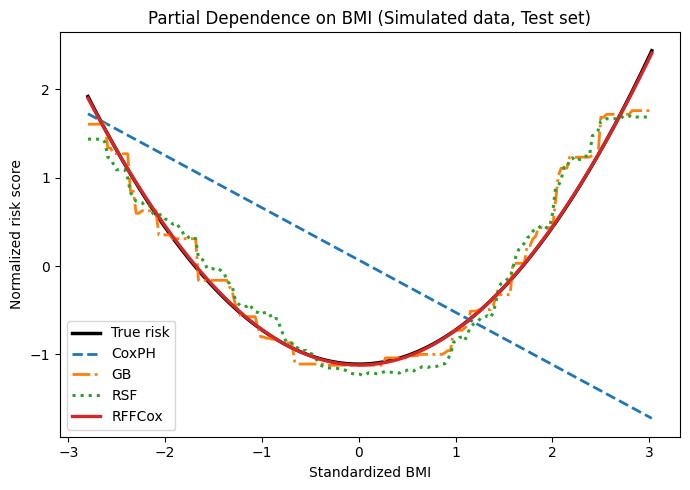

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# 1. Veri yükle (simülasyon)
# ------------------------------------------------------------
X_scaled, T, E, feature_names, true_eta = load_data("simulated", return_true_eta=True)

# ------------------------------------------------------------
# 2. SPLIT
# ------------------------------------------------------------
X_train, X_test, T_train, T_test, E_train, E_test, true_eta_train, true_eta_test = train_test_split(
    X_scaled, T, E, true_eta, test_size=0.2, random_state=42, stratify=E
)

# ------------------------------------------------------------
# 3. Modelleri eğit (SADECE TRAIN ile)
# ------------------------------------------------------------
# RFCox (KRAL)
rfcox = RFCox(m=120, l2=1e-3, seed=42)
rfcox.fit(X_train, T_train, E_train)

# CoxPH
from sksurv.linear_model import CoxPHSurvivalAnalysis
y_train = pd.DataFrame({"event": E_train.astype(bool), "time": T_train})
y_train_sksurv = y_train.to_records(index=False)
coxph = CoxPHSurvivalAnalysis(alpha=1e-3).fit(X_train, y_train_sksurv)

# GB & RSF
from sksurv.ensemble import GradientBoostingSurvivalAnalysis, RandomSurvivalForest
gb = GradientBoostingSurvivalAnalysis(n_estimators=100, random_state=42).fit(X_train, y_train_sksurv)
rsf = RandomSurvivalForest(n_estimators=100, random_state=42, n_jobs=1).fit(X_train, y_train_sksurv)

# ------------------------------------------------------------
# 4. Partial Dependence (BMI - sütun 1) → TEST VERİSİ ÜZERİNDE
# ------------------------------------------------------------
def normalize(z):
    return (z - z.mean()) / (z.std() + 1e-8)

# Grid: BMI değerleri (test verisinden min-max al)
grid = np.linspace(X_test[:, 1].min(), X_test[:, 1].max(), 200)

# Referans: test verisinin ortalaması
X_ref = X_test.mean(axis=0)
X_grid = np.tile(X_ref, (len(grid), 1))
X_grid[:, 1] = grid

# True risk (sadece test için)
true_eta_grid = (
    1.3 * np.tanh(X_grid[:, 0]) +
    0.9 * (X_grid[:, 1] ** 2) -
    1.1 * X_grid[:, 2] * X_grid[:, 3] +
    0.5 * X_grid[:, 4] +
    0.7 * np.log1p(X_grid[:, 5] ** 2)
)

# Tahminler (test grid'i üzerinde)
eta_cox   = coxph.predict(X_grid)          # log-risk
eta_rfcox = rfcox.predict(X_grid)         # log-risk
eta_gb    = gb.predict(X_grid)            # expected time → ters çevir gerekmez çünkü PDP'de sadece trend önemli
eta_rsf   = rsf.predict(X_grid)           # expected time

# Normalize
true_eta_grid = normalize(true_eta_grid)
eta_cox       = normalize(eta_cox)
eta_rfcox     = normalize(eta_rfcox)
eta_gb        = normalize(eta_gb)
eta_rsf       = normalize(eta_rsf)

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(grid, true_eta_grid, color="black", linewidth=2.5, label="True risk")
plt.plot(grid, eta_cox,       linestyle="--",  linewidth=2, label="CoxPH")
plt.plot(grid, eta_gb,        linestyle="-.",  linewidth=2, label="GB")
plt.plot(grid, eta_rsf,       linestyle=":",   linewidth=2.2, label="RSF")
plt.plot(grid, eta_rfcox,     linestyle="-",   linewidth=2.4, label="RFFCox")

plt.xlabel("Standardized BMI")
plt.ylabel("Normalized risk score")
plt.title("Partial Dependence on BMI (Simulated data, Test set)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CV DEĞERLENDİRME (GÜNCELLEŞMİŞ)
# ============================================================
def run_cv_evaluation(
    X, T, E, feature_names,
    models=None,
    cv_folds=5,
    m_rff=40,
    l2_penalty=1e-1,
    random_state=42
):
    import time
    from sklearn.model_selection import StratifiedKFold
    from sksurv.util import Surv
    from sksurv.metrics import concordance_index_censored, cumulative_dynamic_auc

    if models is None:
        models = ["rfcox"]

    results = {model: {"c_index": [], "iauc": [], "fit_time": []} for model in models}
    if "rfcox" in models:
        results["rfcox"]["sigma"] = []
        results["rfcox"]["bandwidth_sigma"] = []

    def get_safe_times_for_auc(T_train, E_train, T_test, E_test, n_times=5):
        event_times_train = T_train[E_train == 1]
        if len(event_times_train) < 2:
            return None
        event_times_test = T_test[E_test == 1]
        max_time = min(event_times_train.max(), event_times_test.max()) if len(event_times_test) > 0 else event_times_train.max() * 0.95
        t_min = np.percentile(event_times_train, 5)
        t_max = np.percentile(event_times_train, 95)
        t_max = min(t_max, max_time - 1e-6)
        if t_max <= t_min:
            return None
        times = np.linspace(t_min, t_max, n_times)
        times = times[times < max_time]
        return times if len(times) >= 2 else None

    print(f"Veri: {X.shape}, Event oranı: {E.mean():.1%}")
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, E)):
        print(f"  Fold {fold+1}/{cv_folds}")
        X_tr, T_tr, E_tr = X[train_idx], T[train_idx], E[train_idx]
        X_te, T_te, E_te = X[test_idx], T[test_idx], E[test_idx]

        X_tr_df = pd.DataFrame(X_tr, columns=feature_names)
        X_te_df = pd.DataFrame(X_te, columns=feature_names)

        preprocessor = get_preprocessor(X_tr_df)
        X_tr_scaled = preprocessor.fit_transform(X_tr_df)
        X_te_scaled = preprocessor.transform(X_te_df)

        y_tr = Surv.from_arrays(event=E_tr.astype(bool), time=T_tr)
        y_te = Surv.from_arrays(event=E_te.astype(bool), time=T_te)

        times = get_safe_times_for_auc(T_tr, E_tr, T_te, E_te, n_times=5)
        if times is None:
            continue

        # RFCox (KRAL)
        if "rfcox" in models:
            start = time.time()
            try:
                cox_model = RFCox(m=m_rff, l2=l2_penalty, seed=random_state + fold)
                cox_model.fit(X_tr_scaled, T_tr, E_tr)
                risk, std = cox_model.predict(X_te_scaled, return_std=True)
                bandwidth_sigma = cox_model.sigma_
                t_fit = time.time() - start

                cidx = concordance_index_censored(E_te.astype(bool), T_te, risk)[0]
                auc_vals, _ = cumulative_dynamic_auc(y_tr, y_te, risk, times)
                iauc = np.nanmean(auc_vals)

                results["rfcox"]["c_index"].append(cidx)
                results["rfcox"]["iauc"].append(iauc)
                results["rfcox"]["fit_time"].append(t_fit)
                results["rfcox"]["sigma"].append(np.mean(std))
                results["rfcox"]["bandwidth_sigma"].append(bandwidth_sigma)
            except Exception as e:
                print(f"    Uyarı: RFCox Fold {fold+1} başarısız – {str(e)}")

        # CoxPH
        if "coxph" in models:
            from sksurv.linear_model import CoxPHSurvivalAnalysis
            start = time.time()
            try:
                coxph = CoxPHSurvivalAnalysis(alpha=l2_penalty).fit(X_tr_scaled, y_tr)
                risk = coxph.predict(X_te_scaled)
                t_fit = time.time() - start
                cidx = concordance_index_censored(E_te.astype(bool), T_te, risk)[0]
                auc_vals, _ = cumulative_dynamic_auc(y_tr, y_te, risk, times)
                iauc = np.nanmean(auc_vals)
                results["coxph"]["c_index"].append(cidx)
                results["coxph"]["iauc"].append(iauc)
                results["coxph"]["fit_time"].append(t_fit)
            except Exception as e:
                print(f"    Uyarı: CoxPH Fold {fold+1} başarısız – {str(e)}")

        # RSF
        if "rsf" in models:
            from sksurv.ensemble import RandomSurvivalForest
            start = time.time()
            try:
                rsf = RandomSurvivalForest(n_estimators=100, random_state=random_state + fold, n_jobs=1)
                rsf.fit(X_tr_scaled, y_tr)
                risk = rsf.predict(X_te_scaled)
                t_fit = time.time() - start
                cidx = concordance_index_censored(E_te.astype(bool), T_te, risk)[0]
                auc_vals, _ = cumulative_dynamic_auc(y_tr, y_te, risk, times)
                iauc = np.nanmean(auc_vals)
                results["rsf"]["c_index"].append(cidx)
                results["rsf"]["iauc"].append(iauc)
                results["rsf"]["fit_time"].append(t_fit)
            except Exception as e:
                print(f"    Uyarı: RSF Fold {fold+1} başarısız – {str(e)}")

        # GB
        if "gb" in models:
            from sksurv.ensemble import GradientBoostingSurvivalAnalysis
            start = time.time()
            try:
                gb = GradientBoostingSurvivalAnalysis(n_estimators=100, random_state=random_state + fold)
                gb.fit(X_tr_scaled, y_tr)
                risk = gb.predict(X_te_scaled)
                t_fit = time.time() - start
                cidx = concordance_index_censored(E_te.astype(bool), T_te, risk)[0]
                auc_vals, _ = cumulative_dynamic_auc(y_tr, y_te, risk, times)
                iauc = np.nanmean(auc_vals)
                results["gb"]["c_index"].append(cidx)
                results["gb"]["iauc"].append(iauc)
                results["gb"]["fit_time"].append(t_fit)
            except Exception as e:
                print(f"    Uyarı: GB Fold {fold+1} başarısız – {str(e)}")

    # SONUÇ TABLOSU
    headers = ["Model", "C-index ↑", "iAUC ↑", "Fit Time (s)"]
    if "rfcox" in models:
        headers.extend(["Mean σ (SE)", "Bandwidth σ"])

    total_width = 18 * len(headers)
    print("\n" + "="*total_width)
    print("".join(f"{h:<18}" for h in headers))
    print("="*total_width)

    for model_name in models:
        res = results[model_name]
        if res["c_index"]:
            ci_mean = np.nanmean(res["c_index"]); ci_std = np.nanstd(res["c_index"])
            iauc_mean = np.nanmean(res["iauc"]); iauc_std = np.nanstd(res["iauc"])
            ft_mean = np.nanmean(res["fit_time"]); ft_std = np.nanstd(res["fit_time"])
            def fmt(m, s): return f"{m:.2f} ± {s:.2f}"
            row = [
                f"{model_name:<18}",
                f"{fmt(ci_mean, ci_std):<15}",
                f"{fmt(iauc_mean, iauc_std):<15}",
                f"{fmt(ft_mean, ft_std):<15}"
            ]
            if model_name == "rfcox":
                se_mean = np.nanmean(res["sigma"])
                se_std = np.nanstd(res["sigma"])
                bw_mean = np.nanmean(res["bandwidth_sigma"])
                bw_std = np.nanstd(res["bandwidth_sigma"])
                row.append(f"{se_mean:.3f} ± {se_std:.3f}")
                row.append(f"{bw_mean:.2f} ± {bw_std:.2f}")
            else:
                if "rfcox" in models:
                    row.extend(["–", "–"])
            print("".join(f"{item:<18}" for item in row))
        else:
            base = f"{model_name:<18} nan"
            if "rfcox" in models:
                base += " " * 36 + "–        –"
            print(base)

    return results

Loaded metabric: Train=(1332, 9), Test=(572, 9), Event rate=57.9%
Running m=15, l2=1e-03
Running m=15, l2=1e-02
Running m=15, l2=1e-01
Running m=15, l2=1e+00
Running m=30, l2=1e-03
Running m=30, l2=1e-02
Running m=30, l2=1e-01
Running m=30, l2=1e+00
Running m=50, l2=1e-03
Running m=50, l2=1e-02
Running m=50, l2=1e-01
Running m=50, l2=1e+00
Running m=80, l2=1e-03
Running m=80, l2=1e-02
Running m=80, l2=1e-01
Running m=80, l2=1e+00
Running m=100, l2=1e-03
Running m=100, l2=1e-02
Running m=100, l2=1e-01
Running m=100, l2=1e+00
Running m=120, l2=1e-03
Running m=120, l2=1e-02
Running m=120, l2=1e-01
Running m=120, l2=1e+00
Running m=150, l2=1e-03
Running m=150, l2=1e-02
Running m=150, l2=1e-01
Running m=150, l2=1e+00
Running m=200, l2=1e-03
Running m=200, l2=1e-02
Running m=200, l2=1e-01
Running m=200, l2=1e+00


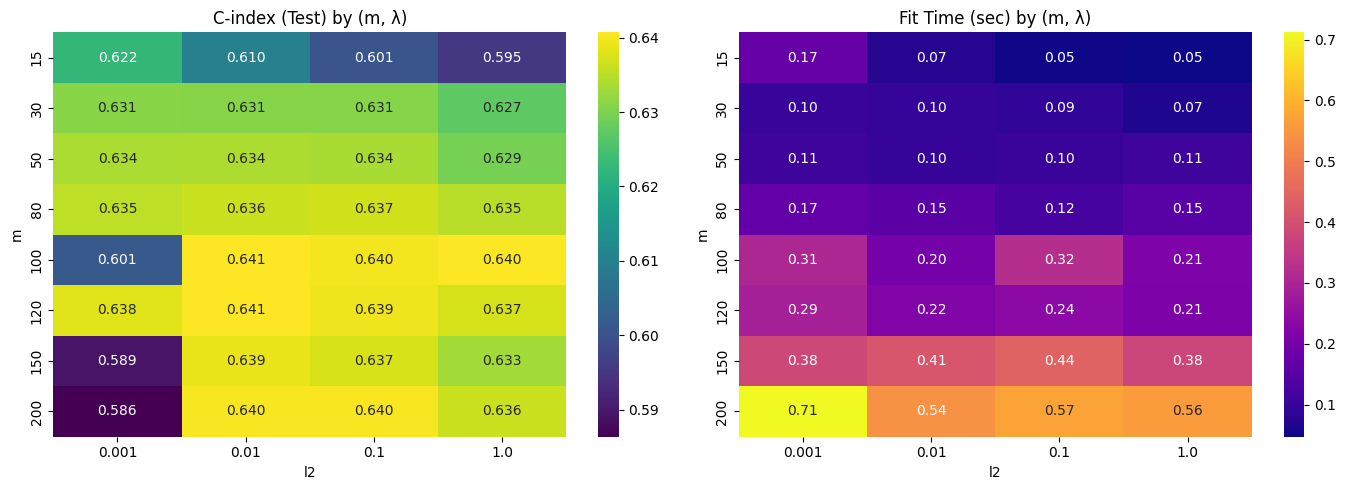


✅ Best C-index (Test):
m               100.000000
l2                0.010000
c_index           0.640727
fit_time_sec      0.199958
Name: 17, dtype: float64

⚡ Fastest fit:
m               15.000000
l2               1.000000
c_index          0.595223
fit_time_sec     0.047143
Name: 3, dtype: float64


In [4]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sksurv.metrics import concordance_index_censored

# ------------------------------------------------------------
# Veriyi yükle
# ------------------------------------------------------------
dataset_name = "metabric"
X_raw, T, E, feature_names = load_data(dataset_name)
X_df = pd.DataFrame(X_raw, columns=feature_names)

# Split (sabit)
X_train_raw, X_test_raw, T_train, T_test, E_train, E_test = train_test_split(
    X_raw, T, E, test_size=0.30, random_state=42, stratify=E
)

# Preprocessing pipeline'ı sadece train'den fit et
X_train_df = pd.DataFrame(X_train_raw, columns=feature_names)
preprocessor = get_preprocessor(X_train_df)
X_train = preprocessor.fit_transform(X_train_df)
X_test = preprocessor.transform(pd.DataFrame(X_test_raw, columns=feature_names))

print(f"Loaded {dataset_name}: Train={X_train.shape}, Test={X_test.shape}, Event rate={E.mean():.1%}")

# ------------------------------------------------------------
# Hiperparametre taraması (sadece TRAIN ile eğit, TEST ile değerlendir)
# ------------------------------------------------------------
results = []
m_values = [15,30,50,80,100,120,150,200]
l2_values = [1e-3,1e-2,1e-1,1.0]

for m in m_values:
    for l2 in l2_values:
        print(f"Running m={m}, l2={l2:.0e}")
        model1 = RFCox(m=m, l2=l2, seed=42)
        
        start = time.perf_counter()
        model1.fit(X_train, T_train, E_train)
        fit_time = time.perf_counter() - start
        
        # ⚠️ TEST verisinde değerlendirme
        log_risk_test = model1.predict(X_test)
        c_idx = concordance_index_censored(E_test.astype(bool), T_test, log_risk_test)[0]
        
        results.append({
            "m": m,
            "l2": l2,
            "c_index": c_idx,
            "fit_time_sec": fit_time
        })

# ------------------------------------------------------------
# Sonuçlar
# ------------------------------------------------------------
df = pd.DataFrame(results)

cidx_pivot = df.pivot(index="m", columns="l2", values="c_index")
time_pivot = df.pivot(index="m", columns="l2", values="fit_time_sec")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cidx_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("C-index (Test) by (m, λ)")

sns.heatmap(time_pivot, annot=True, fmt=".2f", cmap="plasma", ax=axes[1])
axes[1].set_title("Fit Time (sec) by (m, λ)")

plt.tight_layout()
plt.show()

print("\n✅ Best C-index (Test):")
print(df.loc[df["c_index"].idxmax()])

print("\n⚡ Fastest fit:")
print(df.loc[df["fit_time_sec"].idxmin()])

In [5]:
X, T, E, feature_names = load_data("metabric") #metabric# options: "simulated", "rossi", "flchain", "metabric", "support2", "colon", "whas500"
#results = run_cv_evaluation(X, T, E, feature_names, models=["rfcox" ,"coxph", "rsf","gb"]), kernel_cox
results = run_cv_evaluation(X, T, E, feature_names, models=["rfcox"], cv_folds=10, m_rff=100,l2_penalty=1e-1)

NameError: name 'run_cv_evaluation' is not defined

In [ ]:
Veri: metabric(1904, 9), Event oranı: 57.9%, m_rff=100,l2_penalty=1e-1
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.65 ± 0.02       0.70 ± 0.03       0.25 ± 0.03       0.158 ± 0.011     6.83 ± 0.65       
coxph             0.63 ± 0.02       0.68 ± 0.04       0.16 ± 0.05       –                 –                 
rsf               0.65 ± 0.03       0.69 ± 0.05       15.11 ± 0.21      –                 –                 
gb                0.64 ± 0.03       0.69 ± 0.04       5.06 ± 0.02       –                 –  

In [ ]:
Veri: metabric(1904, 9), Event oranı: 57.9%, m_rff=100,l2_penalty=1e-1
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.65 ± 0.02       0.70 ± 0.03       0.25 ± 0.03       0.158 ± 0.011     6.83 ± 0.65       
coxph             0.63 ± 0.02       0.68 ± 0.04       0.16 ± 0.05       –                 –                 
rsf               0.65 ± 0.03       0.69 ± 0.05       15.11 ± 0.21      –                 –                 
gb                0.64 ± 0.03       0.69 ± 0.04       5.06 ± 0.02       –                 –  

Veri: support2(9105, 52), Event oranı: 68.1%, m_rff=120,l2_penalty=1e-1
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.82 ± 0.01       0.87 ± 0.01       1.41 ± 0.07       0.123 ± 0.003     51.98 ± 2.18           
coxph             0.82 ± 0.01       0.87 ± 0.01       1.09 ± 0.29       –                 –                 
rsf               0.78 ± 0.01       0.84 ± 0.01       85.08 ± 9.98      –                 –                 
gb                0.85 ± 0.01       0.89 ± 0.01       125.79 ± 10.68    –                 –             

Veri: flchain(7874, 8), Event oranı: 27.5%,  m_rff=30,l2_penalty=1e-0
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.80 ± 0.02       0.82 ± 0.03       0.30 ± 0.03       0.077 ± 0.010     6.88 ± 1.97       
coxph             0.80 ± 0.02       0.82 ± 0.03       0.78 ± 0.03       –                 –                 
rsf               0.79 ± 0.02       0.82 ± 0.03       44.46 ± 0.62      –                 –                 
gb                0.80 ± 0.02       0.82 ± 0.03       64.01 ± 0.75      –                 –          

Veri: rossi(432, 7), Event oranı: 26.4%, m_rff=30,l2_penalty=1e-03
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.72 ± 0.09       0.73 ± 0.09       0.02 ± 0.00       0.345 ± 0.002     4.16 ± 0.59       
coxph             0.70 ± 0.09       0.73 ± 0.07       0.02 ± 0.00       –                 –                 
rsf               0.59 ± 0.06       0.63 ± 0.07       0.16 ± 0.03       –                 –                 
gb                0.69 ± 0.08       0.70 ± 0.05       0.23 ± 0.00       –                 –                 

Veri: whas(500, 6), Event oranı: 43.0%, m_rff=15,l2_penalty=1e-01
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.76 ± 0.02       0.78 ± 0.02       0.04 ± 0.01       0.211 ± 0.016     7.21 ± 0.61       
coxph             0.76 ± 0.02       0.78 ± 0.03       0.03 ± 0.00       –                 –                 
rsf               0.74 ± 0.02       0.77 ± 0.02       0.56 ± 0.01       –                 –                 
gb                0.74 ± 0.02       0.76 ± 0.05       0.32 ± 0.02       –                 –  

Veri: simulated(2000, 6), Event oranı: 77.6%, m_rff=80,l2_penalty=1e-3 
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.84 ± 0.02       0.93 ± 0.02       0.22 ± 0.04       0.166 ± 0.017     8.56 ± 0.65        
coxph             0.68 ± 0.03       0.77 ± 0.03       0.17 ± 0.02       –                 –                 
rsf               0.79 ± 0.02       0.88 ± 0.02       21.29 ± 0.64      –                 –                 
gb                0.77 ± 0.02       0.86 ± 0.03       5.49 ± 0.09       –                 –                 

Veri: gbs2(686, 9), Event oranı: 43.6%, m_rff=18,l2_penalty=1e-1
============================================================================================================
Model             C-index ↑         iAUC ↑            Fit Time (s)      Mean σ (SE)       Bandwidth σ       
============================================================================================================
rfcox             0.69 ± 0.04       0.73 ± 0.06       0.04 ± 0.01       0.196 ± 0.012     7.84 ± 2.41       
coxph             0.69 ± 0.06       0.73 ± 0.06       0.07 ± 0.01       –                 –                 
rsf               0.69 ± 0.06       0.73 ± 0.06       0.96 ± 0.02       –                 –                 
gb                0.69 ± 0.05       0.72 ± 0.06       0.60 ± 0.03       –                 –                 

In [39]:
from sklearn.feature_selection import VarianceThreshold
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
# ============================================================
# DATASET
# ============================================================
dataset_name = "metabric"
X_raw, T_days, E, feature_names = load_data(dataset_name)  # T_days = GÜN

# ✅ DOĞRU: GÜN → AY (load_data zaten yapıyor, ama emin olalım)
T_months = T_days  # çünkü load_metabric_data() zaten /30.44 yapmış

print("Dataset:", dataset_name)
print("X shape:", X_raw.shape, "Events:", E.mean())
print(f"Time range: {T_months.min():.1f} – {T_months.max():.1f} months")

# DataFrame'e çevir
X_df = pd.DataFrame(X_raw, columns=feature_names)

# ============================================================
# ÖN İŞLEME: SAYISAL vs BINARY/KATEGORİK
# ============================================================
preprocessor = get_preprocessor(X_df)
X_processed = preprocessor.fit_transform(X_df)

# ============================================================
# SPLIT + GLOBAL INDEX KAYDET
# ============================================================
indices = np.arange(len(X_processed))  # global indexler
X_train, X_test, T_train, T_test, E_train, E_test, idx_train, idx_test = train_test_split(
    X_processed, T_months, E, indices,
    test_size=0.30, random_state=42, stratify=E
)

# ============================================================
# MODEL
# ============================================================
rfcox = RFCox(m=100, l2=1e-1, seed=42)
rfcox.fit(X_train, T_train, E_train)
print("Sigma selected:", rfcox.sigma_)
model=rfcox
coxph = CoxPHSurvivalAnalysis(alpha=10.0)
y_train = Surv.from_arrays(event=E_train.astype(bool), time=T_train)
coxph.fit(X_train, y_train)


Dataset: metabric
X shape: (1904, 9) Events: 0.5793067226890757
Time range: 0.0 – 355.2 months
Sigma selected: 6.8518022820646065


CoxPHSurvivalAnalysis(alpha=10.0)

In [25]:
import numpy as np
import statsmodels.api as sm
from sksurv.nonparametric import kaplan_meier_estimator

def ipcw_calibration(model, X_test, T_test, E_test, TIME_POINT=36.0):
    
    # --------------------------------------------------------
    # 1. Predicted survival at TIME_POINT
    # --------------------------------------------------------
    
    t_eval = np.linspace(0, np.percentile(T_test, 90), 200)
    S_pred, _, _ = model.predict_survival_fast_ci(X_test, t_eval, z=1.96)
    idx_t = np.argmin(np.abs(t_eval - TIME_POINT))
    
    S_hat = np.clip(S_pred[:, idx_t], 1e-6, 1-1e-6)
    
    # --------------------------------------------------------
    # 2. Observed survival indicator
    # --------------------------------------------------------
    
    Y = (T_test > TIME_POINT).astype(int)
    
    # --------------------------------------------------------
    # 3. IPCW weights
    # --------------------------------------------------------
    
    censor_event = (E_test == 0)
    times_c, G_hat = kaplan_meier_estimator(censor_event, T_test)
    
    def G_of_t(t):
        if t > times_c[-1]:
            return G_hat[-1]
        idx = np.searchsorted(times_c, t, side="right") - 1
        return G_hat[max(idx, 0)]
    
    weights = np.zeros_like(T_test, dtype=float)
    
    for i in range(len(T_test)):
        if T_test[i] <= TIME_POINT and E_test[i] == 1:
            weights[i] = 1.0 / max(G_of_t(T_test[i]), 1e-6)
        elif T_test[i] > TIME_POINT:
            weights[i] = 1.0 / max(G_of_t(TIME_POINT), 1e-6)
        else:
            weights[i] = 0.0
    
    # --------------------------------------------------------
    # 4. Logistic recalibration
    # --------------------------------------------------------
    
    logit_S = np.log(S_hat / (1 - S_hat))
    X_design = sm.add_constant(logit_S)
    
    glm_model = sm.GLM(
        Y,
        X_design,
        family=sm.families.Binomial(),
        freq_weights=weights
    )
    
    result = glm_model.fit()
    
    intercept, slope = result.params
    
    # --------------------------------------------------------
    # 5. Calibrated predictions
    # --------------------------------------------------------
    
    linear_pred = intercept + slope * logit_S
    S_cal = 1 / (1 + np.exp(-linear_pred))
    
    # --------------------------------------------------------
    # 6. CORRECT ICI (weighted |raw - calibrated|)
    # --------------------------------------------------------
    
    abs_diff = np.abs(S_hat - S_cal)
    ICI = np.sum(weights * abs_diff) / np.sum(weights)
    
    # --------------------------------------------------------
    # 7. Output
    # --------------------------------------------------------
    
    print("\n===========================================")
    print(f"IPCW Calibration @ {TIME_POINT} months")
    print("===========================================")
    print(f"Calibration Intercept : {intercept:.4f}")
    print(f"Calibration Slope     : {slope:.4f}")
    print(f"ICI (corrected)       : {ICI:.4f}")
    print("===========================================\n")
    
    return {
        "intercept": intercept,
        "slope": slope,
        "ICI": ICI,
        "model_summary": result.summary()
    }


In [40]:
calib_results = ipcw_calibration(
    model,
    X_test,
    T_test,
    E_test,
    TIME_POINT=36
)



IPCW Calibration @ 36 months
Calibration Intercept : 0.0623
Calibration Slope     : 0.9659
ICI (corrected)       : 0.0018



In [11]:
def ipcw_calibration_with_band(model, X_test, T_test, E_test, TIME_POINT=24.0):
    import numpy as np
    import matplotlib.pyplot as plt
    import statsmodels.api as sm
    from sksurv.nonparametric import kaplan_meier_estimator

    # --------------------------------------------------
    # 1. Prediction (with KRAL uncertainty inside)
    # --------------------------------------------------
    t_eval = np.linspace(0, np.percentile(T_test, 90), 200)
    S_pred, _, _ = model.predict_survival_fast_ci(X_test, t_eval, z=1.96)
    idx_t = np.argmin(np.abs(t_eval - TIME_POINT))
    S_hat = np.clip(S_pred[:, idx_t], 1e-6, 1-1e-6)

    Y = (T_test > TIME_POINT).astype(int)

    # --------------------------------------------------
    # 2. IPCW weights
    # --------------------------------------------------
    censor_event = (E_test == 0)
    times_c, G_hat = kaplan_meier_estimator(censor_event, T_test)

    def G_of_t(t):
        if t > times_c[-1]:
            return G_hat[-1]
        idx = np.searchsorted(times_c, t, side="right") - 1
        return G_hat[max(idx, 0)]

    weights = np.zeros_like(T_test, dtype=float)

    for i in range(len(T_test)):
        if T_test[i] <= TIME_POINT and E_test[i] == 1:
            weights[i] = 1.0 / max(G_of_t(T_test[i]), 1e-6)
        elif T_test[i] > TIME_POINT:
            weights[i] = 1.0 / max(G_of_t(TIME_POINT), 1e-6)
        else:
            weights[i] = 0.0

    # --------------------------------------------------
    # 3. Logistic calibration model
    # --------------------------------------------------
    logit_S = np.log(S_hat / (1 - S_hat))
    X_design = sm.add_constant(logit_S)

    glm_model = sm.GLM(
        Y,
        X_design,
        family=sm.families.Binomial(),
        freq_weights=weights
    )

    result = glm_model.fit()

    intercept, slope = result.params
    cov = result.cov_params()

    # --------------------------------------------------
    # 4. Curve + Confidence band
    # --------------------------------------------------
    grid = np.linspace(0.001, 0.999, 300)
    logit_grid = np.log(grid / (1 - grid))
    Xg = sm.add_constant(logit_grid)

    pred = result.predict(Xg)

    # Delta method variance
    var = np.sum(Xg @ cov * Xg, axis=1)
    se = np.sqrt(var)

    lower = result.predict(Xg, linear=True) - 1.96 * se
    upper = result.predict(Xg, linear=True) + 1.96 * se

    # Logistic transform
    lower = 1 / (1 + np.exp(-lower))
    upper = 1 / (1 + np.exp(-upper))

    # --------------------------------------------------
    # 5. Plot
    # --------------------------------------------------
    plt.figure(figsize=(8,8))

    plt.plot([0,1],[0,1],'k--',label="Ideal")
    plt.plot(grid, pred, linewidth=3, label="Calibration Curve")
    plt.fill_between(grid, lower, upper, alpha=0.25, label="95% CI Band")

    plt.xlabel(f"Predicted Survival (@ {TIME_POINT} months)")
    plt.ylabel("Observed Survival (IPCW adjusted)")
    plt.title(f"RFCox Calibration\nIntercept={intercept:.3f} | Slope={slope:.3f}")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


In [12]:
def ipcw_calibration_with_band(model, X_test, T_test, E_test, TIME_POINT=36.0):
    import numpy as np
    import matplotlib.pyplot as plt
    import statsmodels.api as sm
    from sksurv.nonparametric import kaplan_meier_estimator

    # --------------------------------------------------
    # 1. Prediction (KRAL uncertainty dahil)
    # --------------------------------------------------
    t_eval = np.linspace(0, np.percentile(T_test, 90), 200)
    S_pred, _, _ = model.predict_survival_fast_ci(X_test, t_eval, z=1.96)
    idx_t = np.argmin(np.abs(t_eval - TIME_POINT))
    S_hat = np.clip(S_pred[:, idx_t], 1e-6, 1 - 1e-6)

    Y = (T_test > TIME_POINT).astype(int)

    # --------------------------------------------------
    # 2. IPCW weights
    # --------------------------------------------------
    censor_event = (E_test == 0)
    times_c, G_hat = kaplan_meier_estimator(censor_event, T_test)

    def G_of_t(t):
        if t > times_c[-1]:
            return G_hat[-1]
        idx = np.searchsorted(times_c, t, side="right") - 1
        return G_hat[max(idx, 0)]

    weights = np.zeros_like(T_test, dtype=float)

    for i in range(len(T_test)):
        if T_test[i] <= TIME_POINT and E_test[i] == 1:
            weights[i] = 1.0 / max(G_of_t(T_test[i]), 1e-6)
        elif T_test[i] > TIME_POINT:
            weights[i] = 1.0 / max(G_of_t(TIME_POINT), 1e-6)
        else:
            weights[i] = 0.0

    # --------------------------------------------------
    # 3. Logistic calibration modeli
    # --------------------------------------------------
    logit_S = np.log(S_hat / (1 - S_hat))
    X_design = sm.add_constant(logit_S)

    glm_model = sm.GLM(
        Y,
        X_design,
        family=sm.families.Binomial(),
        freq_weights=weights
    )

    result = glm_model.fit()

    intercept, slope = result.params
    cov = result.cov_params()

    # --------------------------------------------------
    # 4. ICI (DÜZELTİLDİ: Ham vs Kalibre Edilmiş Tahmin Farkı)
    # --------------------------------------------------
    # Önce kalibre edilmiş tahminleri hesapla
    linear_pred = intercept + slope * logit_S
    S_cal = 1 / (1 + np.exp(-linear_pred))
    
    # ICI = Ağırlıklı ortalama |Ham Tahmin - Kalibre Tahmin|
    ici = np.sum(weights * np.abs(S_hat - S_cal)) / np.sum(weights)

    # --------------------------------------------------
    # 5. Curve + Confidence band
    # --------------------------------------------------
    grid = np.linspace(0.001, 0.999, 300)
    logit_grid = np.log(grid / (1 - grid))
    Xg = sm.add_constant(logit_grid)

    pred = result.predict(Xg)

    # Delta method variance
    var = np.sum(Xg @ cov * Xg, axis=1)
    se = np.sqrt(var)

    lower = result.predict(Xg, linear=True) - 1.96 * se
    upper = result.predict(Xg, linear=True) + 1.96 * se

    lower = 1 / (1 + np.exp(-lower))
    upper = 1 / (1 + np.exp(-upper))

    # --------------------------------------------------
    # 6. Plot
    # --------------------------------------------------
    plt.figure(figsize=(8, 8))

    plt.plot([0, 1], [0, 1], 'k--', label="Ideal")
    plt.plot(grid, pred, linewidth=3, label="Calibration Curve")
    plt.fill_between(grid, lower, upper, alpha=0.25, label="95% CI Band")

    # Metrics kutusu
    textstr = (
        f"Intercept = {intercept:.3f}\n"
        f"Slope = {slope:.3f}\n"
        f"ICI = {ici:.4f}"  # Düzeltildi
    )

    plt.text(
        0.05, 0.95, textstr,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle="round", alpha=0.2)
    )

    plt.xlabel(f"Predicted Survival (@ {TIME_POINT} months)")
    plt.ylabel("Observed Survival (IPCW adjusted)")
    plt.title("RFF-Cox Calibration")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Console çıktısı
    print("===========================================")
    print(f"IPCW Calibration @ {TIME_POINT:.1f} months")
    print("===========================================")
    print(f"Calibration Intercept : {intercept:.4f}")
    print(f"Calibration Slope     : {slope:.4f}")
    print(f"ICI (corrected)       : {ici:.4f}") # Artık doğru değeri basacak
    print("===========================================")

    return intercept, slope, ici

C:\Users\drfah\AppData\Roaming\Python\Python311\site-packages\statsmodels\genmod\generalized_linear_model.py:985: FutureWarning: linear keyword is deprecated, use which="linear"
  warnings.warn(msg, FutureWarning)


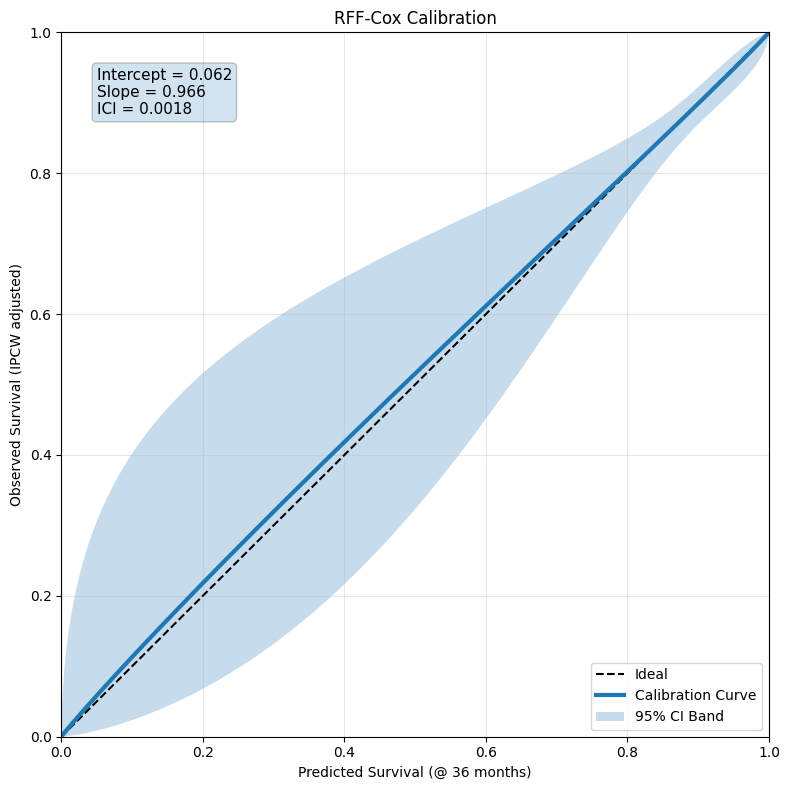

IPCW Calibration @ 36.0 months
Calibration Intercept : 0.0623
Calibration Slope     : 0.9659
ICI (corrected)       : 0.0018


(np.float64(0.06230797829537002),
 np.float64(0.965903037806572),
 np.float64(0.0017503448918894703))

In [41]:
ipcw_calibration_with_band(model, X_test, T_test, E_test, 36)


 Time (months)  Intercept  Slope    ICI  KRAL_CI_Width
            12     0.2409 0.9414 0.0005         0.0122
            24     0.9940 0.6430 0.0104         0.0433
            36     0.0623 0.9659 0.0018         0.0722
            48     0.3564 0.8021 0.0159         0.1048
            60     0.2931 0.7640 0.0205         0.1251
            72     0.1906 0.7910 0.0204         0.1388
            84     0.1256 0.7990 0.0226         0.1515
            96     0.1350 0.7392 0.0310         0.1658
           108    -0.0162 0.8388 0.0271         0.1758
           120    -0.0762 0.9305 0.0223         0.1854
           150    -0.0221 0.9338 0.0103         0.1995
           180    -0.0370 1.1957 0.0248         0.2059
           210    -0.0672 1.1604 0.0262         0.2059
           240     0.0190 1.3283 0.0392         0.1969


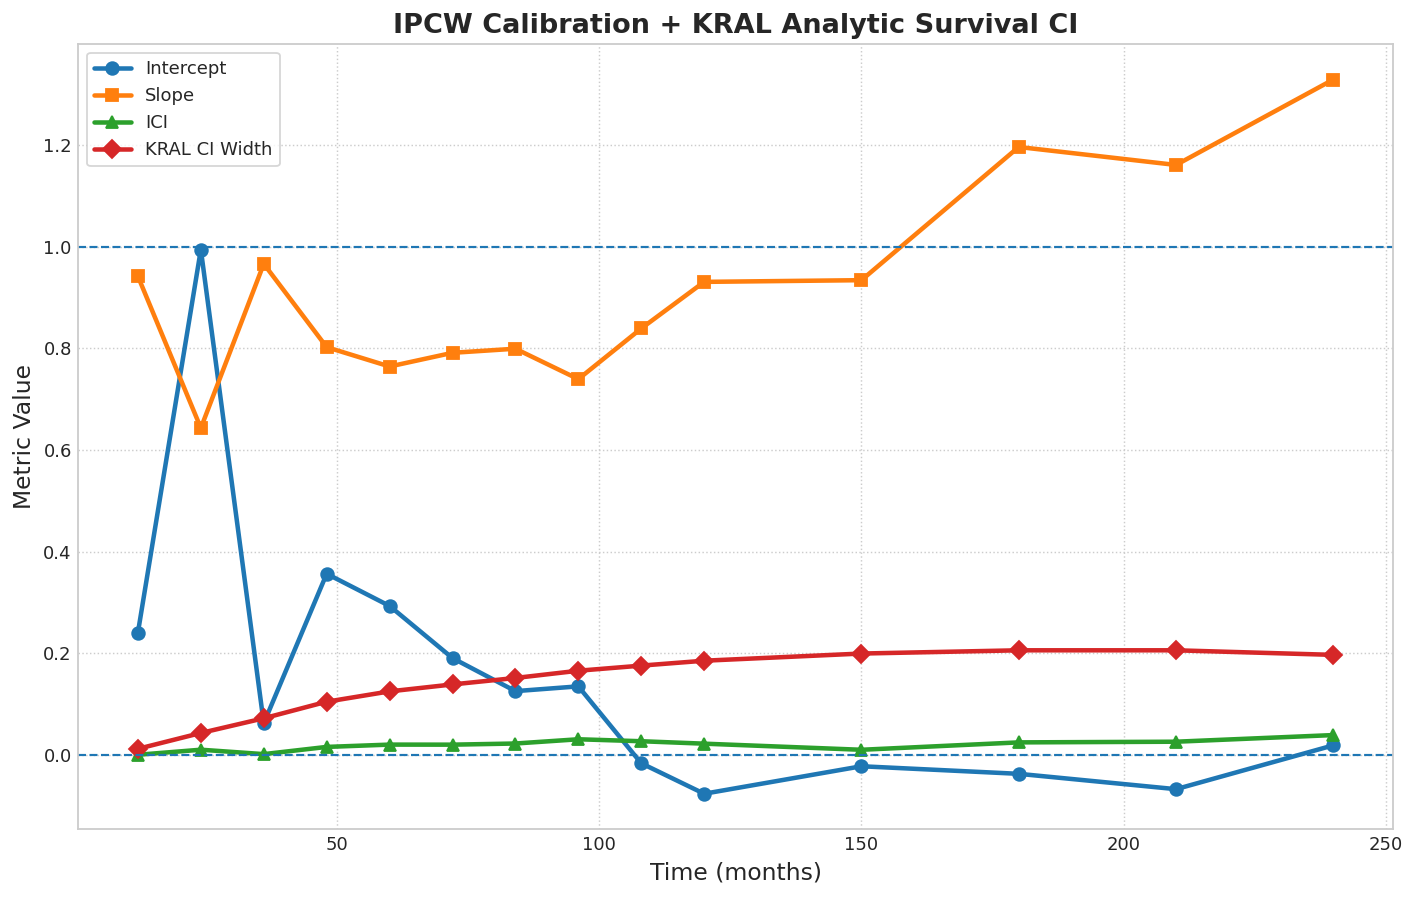

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contextlib
import os

TIME_GRID = [12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 150, 180, 210, 240]

intercepts = []
slopes = []
icis = []
kral_width = []

z = 1.96

for t in TIME_GRID:

    with open(os.devnull, 'w') as f, contextlib.redirect_stdout(f):
        result = ipcw_calibration(model, X_test, T_test, E_test, TIME_POINT=t)

    intercepts.append(result["intercept"])
    slopes.append(result["slope"])
    icis.append(result["ICI"])

    # ===============================
    # KRAL SURVIVAL CI
    # ===============================

    S, lower, upper = model.predict_survival_fast_ci(X_test, t, z=z)

    # Ortalama CI genişliği
    width = np.mean(upper - lower)
    kral_width.append(width)

# ===============================
# TABLE
# ===============================
df = pd.DataFrame({
    "Time (months)": TIME_GRID,
    "Intercept": np.round(intercepts, 4),
    "Slope": np.round(slopes, 4),
    "ICI": np.round(icis, 4),
    "KRAL_CI_Width": np.round(kral_width, 4)
})

print(df.to_string(index=False))

# ===============================
# GRAPH
# ===============================
plt.figure(figsize=(11, 7), dpi=130)

plt.plot(TIME_GRID, intercepts, marker='o', linewidth=2.5, markersize=7, label="Intercept")
plt.plot(TIME_GRID, slopes, marker='s', linewidth=2.5, markersize=7, label="Slope")
plt.plot(TIME_GRID, icis, marker='^', linewidth=2.5, markersize=7, label="ICI")
plt.plot(TIME_GRID, kral_width, marker='D', linewidth=2.5, markersize=7, label="KRAL CI Width")

plt.axhline(0, linestyle="--", linewidth=1.2)
plt.axhline(1, linestyle="--", linewidth=1.2)

plt.grid(True, linestyle=":", linewidth=0.8)

plt.xlabel("Time (months)", fontsize=13)
plt.ylabel("Metric Value", fontsize=13)
plt.title("IPCW Calibration + KRAL Analytic Survival CI", fontsize=15, weight="bold")

plt.legend(frameon=True)
plt.tight_layout()
plt.show()


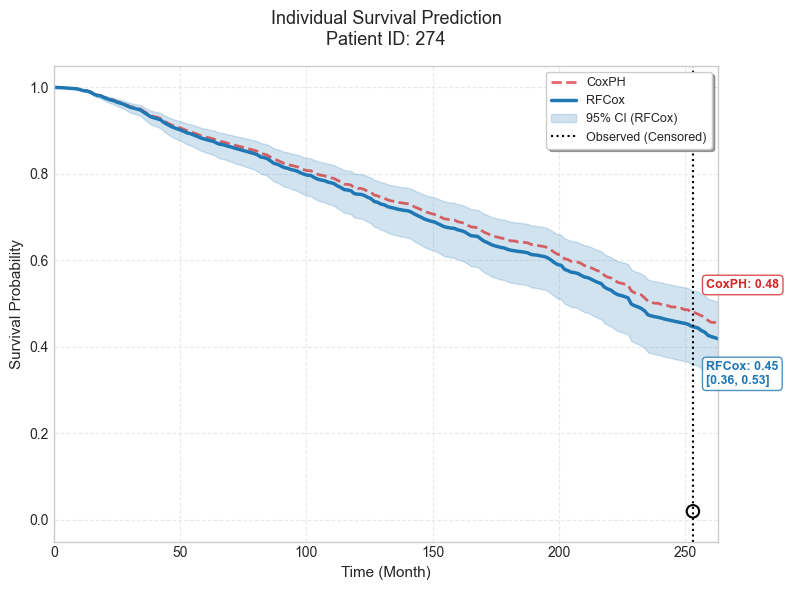


📊 Patient 274:
   Observed time: 252.97 (censored)
   RFCox S(t): 0.448 | 95% CI: [0.360, 0.531]
   CoxPH S(t): 0.479


In [177]:
# ============================================================
# TEK HASTA - DÜZELTİLMİŞ GÖRSELLEŞTİRME
# ============================================================
patient_idx = min(274, len(X_test) - 1)
x_patient = X_test[patient_idx:patient_idx+1]
t_actual = T_test[patient_idx]
e_actual = E_test[patient_idx]

# Zaman grid'i
t_grid = np.linspace(0, np.percentile(T_train, 95), 200)

# ============================================================
# TAHMİNLER
# ============================================================
S_kral, lo_kral, hi_kral = rfcox.predict_survival_fast_ci(x_patient, t_grid, z=1.96)
surv_func_cox = coxph.predict_survival_function(x_patient)[0]
S_cox = surv_func_cox(t_grid)

# ============================================================
# ️ DÜZELTME: S(t) < 1 olan kısımları filtrele
# ============================================================
# Log-Log yöntemi S=1 iken alt sınırı 0 yapar (sonsuz belirsizlik).
# Bu yüzden S(t) belirli bir eşiğin (örn: 0.99) altına inene kadar CI çizmiyoruz.
valid_mask = S_kral[0] < 0.995 

# Eğer hiç valid nokta yoksa (çok nadir), en azından ilk olay zamanından sonrasını al
if not np.any(valid_mask):
    first_event_idx = np.where(S_kral[0] < 1.0)[0]
    if len(first_event_idx) > 0:
        start_idx = first_event_idx[0]
        valid_mask[start_idx:] = True

t_valid = t_grid[valid_mask]
S_valid = S_kral[0, valid_mask]
lo_valid = lo_kral[0, valid_mask]
hi_valid = hi_kral[0, valid_mask]

# ============================================================
# GRAFİK ÇİZİMİ
# ============================================================
plt.figure(figsize=(8, 6)) # Biraz daha geniş

# 1. CoxPH (Arka planda kalsın)
plt.plot(t_grid, S_cox, color='#D62728', linestyle='--', linewidth=2, label="CoxPH", alpha=0.7)

# 2. RFCox (Ön planda)
plt.plot(t_grid, S_kral[0], color='#1F77B4', linewidth=2.5, label="RFCox")

# 3. Güven Aralığı (SADECE geçerli kısımda)
plt.fill_between(t_valid, lo_valid, hi_valid, color='#1F77B4', alpha=0.2, label="95% CI (RFCox)")

# 4. Gözlem (Observed)
plt.axvline(t_actual, color='black', linestyle=':', linewidth=1.5, label=f"Observed ({'Event' if e_actual else 'Censored'})")

# Marker (X ekseni üzerinde)
marker_y = 0.02
if e_actual:
    plt.scatter([t_actual], [marker_y], color='black', s=80, zorder=5, marker='o')
else:
    plt.scatter([t_actual], [marker_y], facecolors='none', edgecolors='black', s=80, zorder=5, marker='o', linewidths=1.5)

# ============================================================
# 📌 METİN ETİKETLERİ (ÇAKIŞMAYACAK ŞEKİLDE AYARLANDI)
# ============================================================
idx_actual = np.argmin(np.abs(t_grid - t_actual))
s_kral_val = S_kral[0, idx_actual]
s_lo = lo_kral[0, idx_actual]
s_hi = hi_kral[0, idx_actual]
s_cox_val = S_cox[idx_actual]

# RFCox Metni (Eğer CI varsa CI'ın içine, yoksa üstüne)
# Dikey konumu dinamik seçelim ki eğrinin üzerine binmesin
offset_y = 0.05 if s_kral_val > 0.5 else -0.08
va_align = 'bottom' if s_kral_val > 0.5 else 'top'

plt.text(
    t_actual + (t_grid.max() - t_grid.min()) * 0.02,
    s_kral_val + offset_y,
    f"RFCox: {s_kral_val:.2f}\n[{s_lo:.2f}, {s_hi:.2f}]",
    color='#1F77B4',
    fontsize=9,
    fontweight='bold',
    verticalalignment=va_align,
    bbox=dict(facecolor='white', edgecolor='#1F77B4', alpha=0.8, boxstyle='round,pad=0.3')
)

# CoxPH Metni (RFCox'un tersi yönde)
offset_y_cox = -0.08 if s_cox_val > 0.5 else 0.05
va_align_cox = 'top' if s_cox_val > 0.5 else 'bottom'

plt.text(
    t_actual + (t_grid.max() - t_grid.min()) * 0.02,
    s_cox_val + offset_y_cox,
    f"CoxPH: {s_cox_val:.2f}",
    color='#D62728',
    fontsize=9,
    fontweight='bold',
    verticalalignment=va_align_cox,
    bbox=dict(facecolor='white', edgecolor='#D62728', alpha=0.8, boxstyle='round,pad=0.3')
)

# ============================================================
# SON DOKUNUŞLAR
# ============================================================
plt.xlabel("Time (Month)", fontsize=11)
plt.ylabel("Survival Probability", fontsize=11)
plt.title(f"Individual Survival Prediction\nPatient ID: {patient_idx}", fontsize=13, pad=15)
plt.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=9)
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(-0.05, 1.05) # Y eksenini biraz ferahlat
plt.xlim(0, t_grid.max())

plt.tight_layout()
plt.show()

# Konsol çıktısı
print(f"\n📊 Patient {patient_idx}:")
print(f"   Observed time: {t_actual:.2f} ({'event' if e_actual else 'censored'})")
print(f"   RFCox S(t): {s_kral_val:.3f} | 95% CI: [{s_lo:.3f}, {s_hi:.3f}]")
print(f"   CoxPH S(t): {s_cox_val:.3f}")

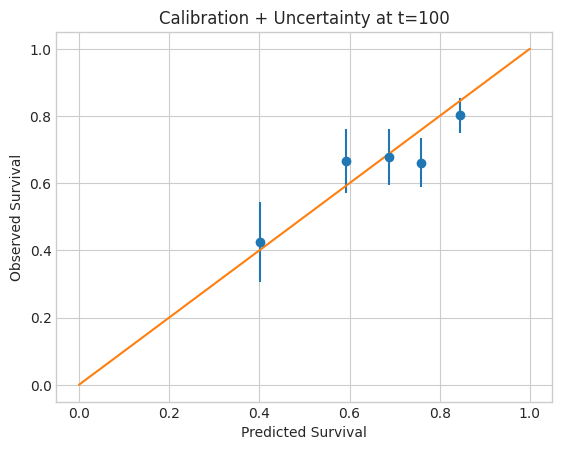

(array([0.40084709, 0.59195784, 0.68700047, 0.75756433, 0.84423258]),
 array([0.42471585, 0.66697427, 0.67778456, 0.6615403 , 0.80181105]))

In [225]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

def kral_calibration_with_uncertainty(model, X, T, E, t0, n_bins=5):

    # 1. Predicted survival + CI
    S_pred, S_lower, S_upper = model.predict_survival_fast_ci(X, t0)
    S_pred = S_pred.flatten()

    # 2. Binleme
    bins = np.quantile(S_pred, np.linspace(0, 1, n_bins + 1))
    bins[0] -= 1e-8
    bins[-1] += 1e-8

    bin_ids = np.digitize(S_pred, bins) - 1

    mean_pred = []
    mean_obs = []
    se_pred_bin = []

    kmf = KaplanMeierFitter()

    for b in range(n_bins):
        mask = (bin_ids == b)
        if np.sum(mask) < 5:
            continue

        # Mean predicted
        mean_pred.append(np.mean(S_pred[mask]))

        # Observed KM estimate at t0
        kmf.fit(T[mask], E[mask])
        mean_obs.append(kmf.predict(t0))

        # Prediction variance band (delta already inside CI)
        width = S_upper[mask] - S_lower[mask]
        se_bin = np.mean(width) / 3.92  # approx: width ≈ 2*z*SE
        se_pred_bin.append(se_bin)

    mean_pred = np.array(mean_pred)
    mean_obs = np.array(mean_obs)
    se_pred_bin = np.array(se_pred_bin)

    # Plot
    plt.figure()
    plt.errorbar(mean_pred, mean_obs,
                 yerr=1.96 * se_pred_bin,
                 fmt='o')

    plt.plot([0,1],[0,1])
    plt.xlabel("Predicted Survival")
    plt.ylabel("Observed Survival")
    plt.title(f"Calibration + Uncertainty at t={t0}")
    plt.show()

    return mean_pred, mean_obs
kral_calibration_with_uncertainty(
    model, X_test, T_test, E_test,
    t0=100,
    n_bins=5
)


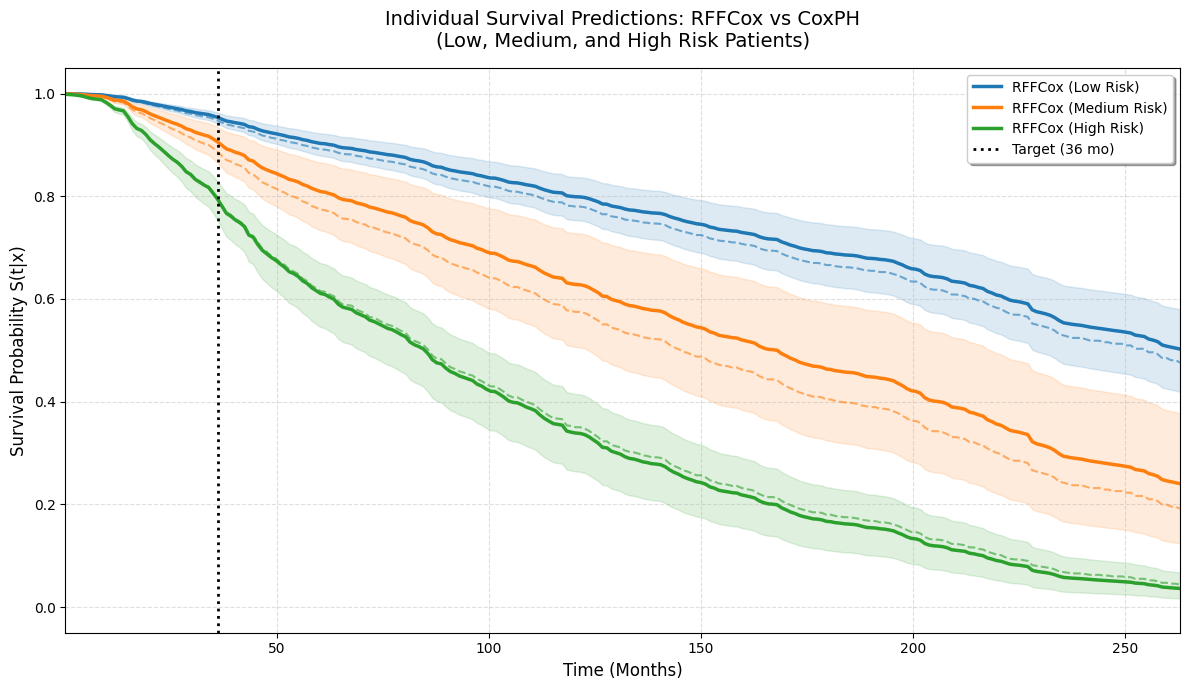


Patient    Group        HR (CoxPH)   HR (RFFCox) [95% CI]      Log-Risk ± SE      S(48mo) RFFCox [95% CI]  
#260       Low Risk     0.60         0.53 [0.42, 0.66]          -0.64 ±  0.12   0.953 [0.942, 0.963]
#523       Medium Risk  1.34         1.09 [0.74, 1.60]           0.09 ±  0.19   0.906 [0.865, 0.935]
#283       High Risk    2.53         2.54 [2.06, 3.12]           0.93 ±  0.11   0.795 [0.754, 0.829]


In [44]:
# ============================================================
# 5) TEMSİLCİ HASTALAR (TEST SETİNDEN) - DÜZELTİLMİŞ
# ============================================================
# Test setinde partial hazard hesapla (Standart exp(eta))
# Not: predict_partial_hazard fonksiyonun artık standart exp(eta) döndürüyor olmalı.
partial_haz_kral_test = rfcox.predict(X_test) # Log-risk
hr_kral_test = np.exp(partial_haz_kral_test)  # HR

idx_sorted = np.argsort(hr_kral_test)
low_id  = idx_sorted[int(0.10 * len(X_test))]
mid_id  = idx_sorted[int(0.50 * len(X_test))]
high_id = idx_sorted[int(0.90 * len(X_test))]
patient_ids = [low_id, mid_id, high_id]
risk_labels = ["Low Risk", "Medium Risk", "High Risk"]

# ============================================================
# 6) SURVIVAL PLOT (DÜZELTİLMİŞ GÖRSELLEŞTİRME)
# ============================================================
t_grid = np.linspace(T_train.min(), np.percentile(T_train, 95), 250)
t_target =36  # 48 ay (Kodda yorum 4 yıl=48 ay demiş, birimlere dikkat et)

# Eğer T_train gün cinsindense ay'a çevirmiş olmalısın, değilse t_target'ı kontrol et.
# Buradaki varsayım: t_grid ve T_train aynı birimde (Ay).

survival_4yr = []
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Mavi, Turuncu, Yeşil

for i, pid in enumerate(patient_ids):
    x_patient = X_test[pid:pid+1]
    
    # RFCox Tahminleri
    S_kral, S_lo, S_hi = rfcox.predict_survival_fast_ci(x_patient, t_grid, z=1.96)
    S_kral_row = S_kral[0]
    S_lo_row = S_lo[0]
    S_hi_row = S_hi[0]
    
    # CoxPH Tahminleri
    surv_func_cox = coxph.predict_survival_function(x_patient)[0]
    S_cox = surv_func_cox(t_grid)
    
    # --- DÜZELTME: Geçerli Maskesi Oluştur ---
    # S(t) < 0.995 olan noktaları al (Başlangıçtaki sonsuz CI sütununu kes)
    valid_mask = S_kral_row < 0.995
    
    # En azından birkaç nokta görünmesi için garanti
    if np.sum(valid_mask) < 5:
        first_drop = np.where(S_kral_row < 1.0)[0]
        if len(first_drop) > 0:
            valid_mask[first_drop[0]:] = True
            
    t_valid = t_grid[valid_mask]
    s_valid = S_kral_row[valid_mask]
    lo_valid = S_lo_row[valid_mask]
    hi_valid = S_hi_row[valid_mask]
    
    # 48. ay tahmini (Interpolasyon veya en yakın nokta)
    if t_target <= t_grid.max() and t_target >= t_grid.min():
        idx = np.argmin(np.abs(t_grid - t_target))
        s_kral = S_kral_row[idx]
        s_lo = S_lo_row[idx]
        s_hi = S_hi_row[idx]
        survival_4yr.append((s_kral, s_lo, s_hi))
    else:
        survival_4yr.append((np.nan, np.nan, np.nan))
    
    # --- ÇİZİM ---
    color = colors[i]
    hr_val = hr_kral_test[pid]
    
    # 1. CoxPH (Kesikli çizgi, arka plan)
    plt.plot(t_grid, S_cox, '--', linewidth=1.5, color=color, alpha=0.6)
    
    # 2. RFCox (Düz çizgi, ön plan)
    plt.plot(t_grid, S_kral_row, linewidth=2.5, color=color, label=f"RFFCox ({risk_labels[i]})")
    
    # 3. Güven Aralığı (SADECE geçerli maskeli kısımda)
    plt.fill_between(t_valid, lo_valid, hi_valid, color=color, alpha=0.15)

# Hedef zaman çizgisi
if t_target <= t_grid.max():
    plt.axvline(t_target, color='black', linestyle=':', linewidth=2, label=f"Target ({t_target} mo)")

plt.title("Individual Survival Predictions: RFFCox vs CoxPH\n(Low, Medium, and High Risk Patients)", fontsize=14, pad=15)
plt.xlabel("Time (Months)", fontsize=12)
plt.ylabel("Survival Probability S(t|x)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc='best', frameon=True, fancybox=True, shadow=True)
plt.ylim(-0.05, 1.05)
plt.xlim(t_grid.min(), t_grid.max())
plt.tight_layout()
plt.show()

# ============================================================
# 7) TABLO (DÜZENLİ ÇIKTI)
# ============================================================
log_risk_kral, std_kral = rfcox.predict(X_test, return_std=True)
hr_kral_all, hr_kral_lo, hr_kral_hi = rfcox.predict_hr_ci(X_test)

print("\n" + "="*130)
print(f"{'Patient':<10} {'Group':<12} {'HR (CoxPH)':<12} {'HR (RFFCox) [95% CI]':<25} {'Log-Risk ± SE':<18} {'S(48mo) RFFCox [95% CI]':<25}")
print("="*130)

for i, pid in enumerate(patient_ids):
    # CoxPH HR
    hr_cox = np.exp(coxph.predict(X_test[pid:pid+1]))[0]
    
    # RFCox HR & CI
    hr_k = hr_kral_all[pid]
    hr_lo = hr_kral_lo[pid]
    hr_hi = hr_kral_hi[pid]
    
    # Log Risk
    lr_kral = log_risk_kral[pid]
    se_kral = std_kral[pid]
    
    # Survival at 48mo
    s_kral, s_lo, s_hi = survival_4yr[i]
    if np.isnan(s_kral):
        s_str = "N/A (Out of range)"
    else:
        s_str = f"{s_kral:.3f} [{s_lo:.3f}, {s_hi:.3f}]"
    
    hr_str = f"{hr_k:.2f} [{hr_lo:.2f}, {hr_hi:.2f}]"
    
    print(f"#{pid:<9} {risk_labels[i]:<12} {hr_cox:<12.2f} {hr_str:<25} {lr_kral:6.2f} ± {se_kral:5.2f}   {s_str}")

print("="*130)

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

def plot_time_calibration(model, X, T, E, t_star=48, n_bins=5):
    """
    Time-dependent calibration plot at time t_star.
    
    Parameters
    ----------
    model : fitted RFCox model
    X, T, E : data
    t_star : time point (e.g., 48 months)
    n_bins : number of quantile groups
    """

    # 1️⃣ Predicted survival
    S_pred = model.predict_survival_function(X, np.array([t_star])).flatten()

    # 2️⃣ Risk bins
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.quantile(S_pred, quantiles)
    groups = np.digitize(S_pred, bins[1:-1], right=True)

    kmf = KaplanMeierFitter()

    pred_means = []
    obs_surv = []

    for g in range(n_bins):
        idx = (groups == g)
        if np.sum(idx) < 10:
            continue

        # predicted mean survival
        pred_means.append(np.mean(S_pred[idx]))

        # observed KM survival at t_star
        kmf.fit(T[idx], E[idx])
        obs_surv.append(kmf.predict(t_star))

    # 3️⃣ Plot
    plt.figure(figsize=(6,6))
    plt.plot([0,1],[0,1],'k--',label="Perfect calibration")
    plt.scatter(pred_means, obs_surv)
    plt.xlabel(f"Predicted S({t_star})")
    plt.ylabel(f"Observed KM S({t_star})")
    plt.title(f"Time-dependent Calibration at {t_star}")
    plt.xlim(0,1)
    plt.ylim(0,1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


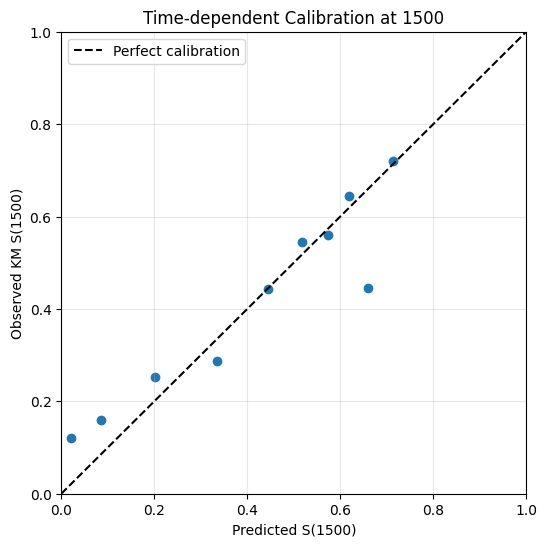

In [293]:
# veri yükle
X, T, E, feature_names = load_data("liver")

# modeli eğit
model = RFCox(m=20, l2=1e-1, seed=42)
model.fit(X, T, E)

# 48 ay kalibrasyon
plot_time_calibration(model, X, T, E, t_star=1500, n_bins=10)
